## Evaluate saved posterior (summary stats)
Load a pre-trained summary-stats posterior.pkl and run diagnostics without retraining.

In [1]:
import pickle
import numpy as np
import scipy as sps
import matplotlib.pyplot as plt

import torch
from torch.utils import data

import ili
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2026-04-17 13:37:10.563987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776447430.628390   75540 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776447430.647173   75540 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 13:37:10.781269: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/puehlengt/.local/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refacto

## Config — edit to match the run you want to evaluate

In [2]:
# Model
MODEL_DIR = '3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3'

# Data
DATA_PATH = '/home/puehlengt/appletree/notebooks/harvested_testsims_3params.npy'
NUM_SAMPLES = 50000

# Split (must match training)
SEED = 42
N_TEST = 10
VALIDATION_FRACTION = 0.1


## Load simulations

In [3]:
aa = np.load(DATA_PATH, allow_pickle=True).item()
param_bag = aa['param_bag']
events_bag = aa['events_bag']

In [4]:
apt_param_config = {
    'g1': {
        'prior_args': {'mean': 0.1367, 'std': 0.001},
        'init_mean': 0.1367, 'init_std': 0.001,
        'allowed_range': [0, 1.0],
        'unit': 'PE/photon',
    },
    'g2': {
        'prior_args': {'mean': 16.85, 'std': 0.46},
        'init_mean': 16.85, 'init_std': 0.46,
        'allowed_range': [0, 100.0],
        'unit': 'PE/electron',
    },
    'ambe_nr_rate': {
        'prior_args': {},
        'init_mean': 5500, 'init_std': 100,
        'allowed_range': [0, 10000000000.0],
        'unit': '1',
    },
}

## Reproduce train/val/test split

In [5]:
np.random.seed(SEED)
permuted_idx = np.random.permutation(NUM_SAMPLES)
idx_test = permuted_idx[:N_TEST]
idx_remaining = permuted_idx[N_TEST:]
n_train = int((1 - VALIDATION_FRACTION) * len(idx_remaining))
idx_train = idx_remaining[:n_train]
idx_val = idx_remaining[n_train:]
print(f'train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}')

train: 44991, val: 4999, test: 10


## Build summary stats dataset

In [6]:
def make_summary(events):
    cs1 = events[0]
    log_cs2 = np.log10(events[1])
    n_events = len(cs1)
    return np.array([
        np.mean(cs1),
        np.std(cs1),
        np.mean(log_cs2),
        np.std(log_cs2),
        float(n_events),
    ], dtype=np.float32)


x_data = []
theta_data = []
for idx in range(NUM_SAMPLES):
    x_data.append(make_summary(events_bag[idx]))
    theta_data.append(np.array([v for v in param_bag[idx].values()], dtype=np.float32))

x_data = np.stack(x_data)
theta_data = torch.tensor(np.stack(theta_data))
print(f'x_data: {x_data.shape}, theta_data: {theta_data.shape}')


x_data: (50000, 5), theta_data: torch.Size([50000, 3])


In [7]:
with open(f'{MODEL_DIR}/x_norm_stats.pkl', 'rb') as f:
    norm_stats = pickle.load(f)
x_mean = norm_stats['x_mean']
x_std  = norm_stats['x_std']
x_data = torch.tensor((x_data - x_mean) / x_std, dtype=torch.float32)
print('Applied z-norm from training stats.')


Applied z-norm from training stats.


## Load posterior

In [8]:
pkl_path = f'{MODEL_DIR}/posterior.pkl'
with open(pkl_path, 'rb') as f:
    posterior_ensemble = pickle.load(f)
print('Loaded:', pkl_path)

Loaded: 3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3/posterior.pkl


## Single posterior — first test example

In [9]:
ind = 0
test_idx = idx_test[ind]
x_ = x_data[test_idx]
y_ = theta_data[test_idx].numpy()

torch.manual_seed(1234)
samples = posterior_ensemble.sample((1000,), x_)
log_prob = posterior_ensemble.log_prob(samples, x_)
samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 1616.80it/s]


## Fisher information from summary statistics
Linear regression t ~ θ on training sims → gradient A (5×3), residual covariance Σ, FIM = Aᵀ Σ⁻¹ A → Cramér-Rao bounds.

To see if NSF NPE extracted the max information from the summary stats rep (plus information from the prior, which can be interpreted as the Gaussian constraint on the parameters in the likelihood.). (It did.) But still doesn't answer question of whether I'm milk the max from the information available in the raw data.

In [20]:

# Raw summary stats (pre-z-norm) — rebuild from data already in memory
x_raw = np.stack([make_summary(events_bag[i]) for i in range(NUM_SAMPLES)])
theta_raw = theta_data.numpy()  # (N, 3)

# Linear regression on training set: t ~ Aθ + b
X_tr = theta_raw[idx_train]
Y_tr = x_raw[idx_train]
X_aug = np.hstack([X_tr, np.ones((len(X_tr), 1))])
coeff, _, _, _ = np.linalg.lstsq(X_aug, Y_tr, rcond=None)  # (4, 5)

# A[d, j] = dE[t_d]/dtheta_j,  shape (5, 3)
A = coeff[:3].T

# Residual covariance and summary-stat Fisher info
residuals = Y_tr - X_aug @ coeff
Sigma_t = np.cov(residuals.T)
F_data = A.T @ np.linalg.inv(Sigma_t) @ A  # (3, 3)

# Prior Fisher info: Gaussian prior contributes diag(1/prior_sigma^2)
prior_stds = np.array([apt_param_config[k]['prior_args'].get('std', apt_param_config[k]['init_std'])
                       for k in param_names])
F_prior = np.diag(1.0 / prior_stds**2)

# Combined Fisher info (data + prior)
F_total = F_data + F_prior
cr_bounds = np.sqrt(np.diag(np.linalg.inv(F_total)))

print("Cramér-Rao lower bounds (data + prior Fisher):")
for name, cr, ps in zip(param_names, cr_bounds, prior_stds):
    print(f"  {name:20s}  σ_CR = {cr:.4g}   prior σ = {ps:.4g}")


Cramér-Rao lower bounds (data + prior Fisher):
  g1                    σ_CR = 0.0007495   prior σ = 0.001
  g2                    σ_CR = 0.0599   prior σ = 0.46
  ambe_nr_rate          σ_CR = 59.41   prior σ = 100


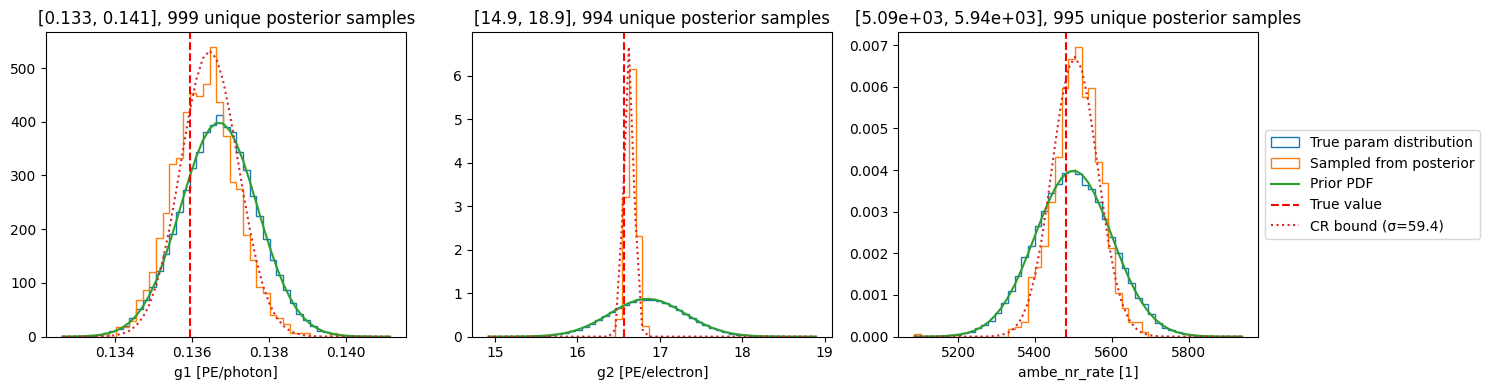

In [ ]:
zzparams = theta_data.numpy()
param_names = list(apt_param_config.keys())

plt.figure(figsize=(15, 4))
for _ii, (key, val) in enumerate(apt_param_config.items()):
    zzz = zzparams[:, _ii]
    zzmin, zzmax = zzz.min(), zzz.max()
    zzxx = np.linspace(zzmin, zzmax, 50)
    zzmean = val['prior_args'].get('mean', val['init_mean'])
    zzstd  = val['prior_args'].get('std',  val['init_std'])

    plt.subplot(131 + _ii)
    plt.hist(zzz, bins=zzxx, density=True, histtype='step', label='True param distribution')
    plt.hist(samples[:, _ii], bins=zzxx, density=True, histtype='step', label='Sampled from posterior')
    if zzstd > 0:
        plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=zzmean, scale=zzstd), label='Prior PDF')
    plt.axvline(y_[_ii], color='red', linestyle='--', label='True value')

    # CR bound Gaussian centred at posterior mode
    kde = sps.stats.gaussian_kde(samples[:, _ii])
    post_mode = zzxx[np.argmax(kde(zzxx))]
    plt.plot(zzxx, sps.stats.norm.pdf(zzxx, loc=post_mode, scale=cr_bounds[_ii]),
             linestyle=':', label=f'CR bound (σ={cr_bounds[_ii]:.3g})')

    plt.title(f'[{zzmin:.3g}, {zzmax:.3g}], {len(np.unique(samples[:, _ii]))} unique posterior samples')
    plt.xlabel(f'{key} [{val["unit"]}]')
    if _ii == 2:
        plt.legend(loc='center left', bbox_to_anchor=(1., 0.5))
plt.tight_layout()
plt.show()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 26417.15it/s]
INFO:root:Saving single posterior plot to 3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3/plot_single_posterior.jpg...


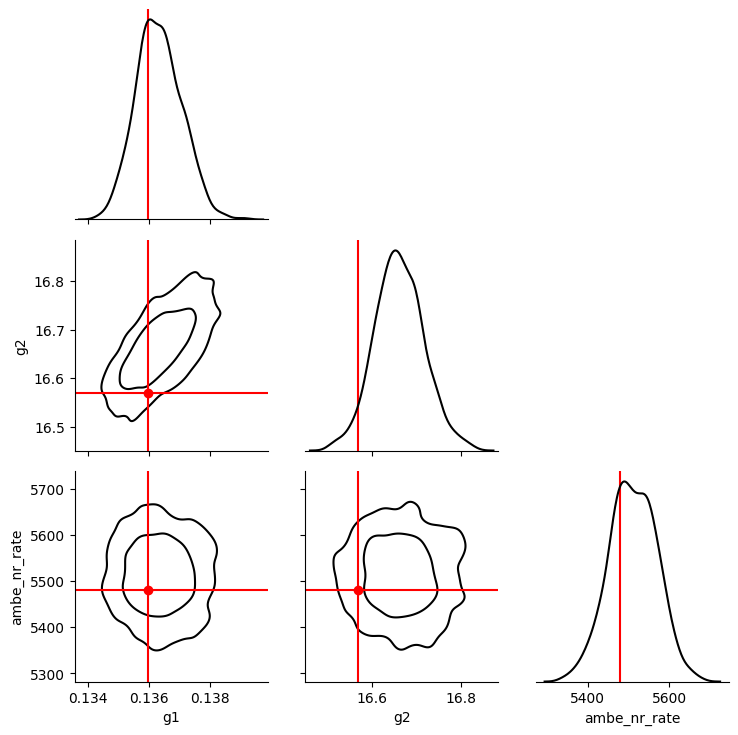

In [11]:
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=param_names,
    out_dir=MODEL_DIR,
)
fig = metric(posterior=posterior_ensemble, x_obs=x_, theta_fid=y_)

## test2 — 2k fresh sims, indices NUM_SAMPLES onwards (never seen during training)

In [12]:
N_TEST2 = 2000
idx_test2 = np.arange(NUM_SAMPLES, NUM_SAMPLES + N_TEST2)

x_test2 = []
theta_test2 = []
for idx in idx_test2:
    x_test2.append(make_summary(events_bag[idx]))
    theta_test2.append(np.array([v for v in param_bag[idx].values()], dtype=np.float32))

x_test2 = torch.tensor((np.stack(x_test2) - x_mean) / x_std, dtype=torch.float32)
theta_test2 = np.stack(theta_test2)
print(f'x_test2: {x_test2.shape}, theta_test2: {theta_test2.shape}')


x_test2: torch.Size([2000, 5]), theta_test2: (2000, 3)


100%|██████████| 2000/2000 [00:31<00:00, 64.32it/s]
INFO:root:Saving posterior samples to 3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3/posterior_samples.npy...
INFO:root:Saving coverage plot to 3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3/plot_coverage.jpg...
INFO:root:Saving ranks histogram to 3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3/ranks_histogram.jpg...
100%|██████████| 100/100 [00:22<00:00,  4.43it/s]


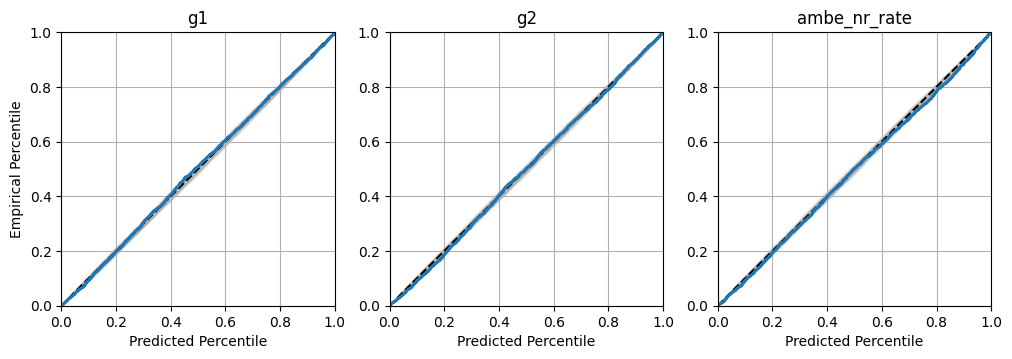

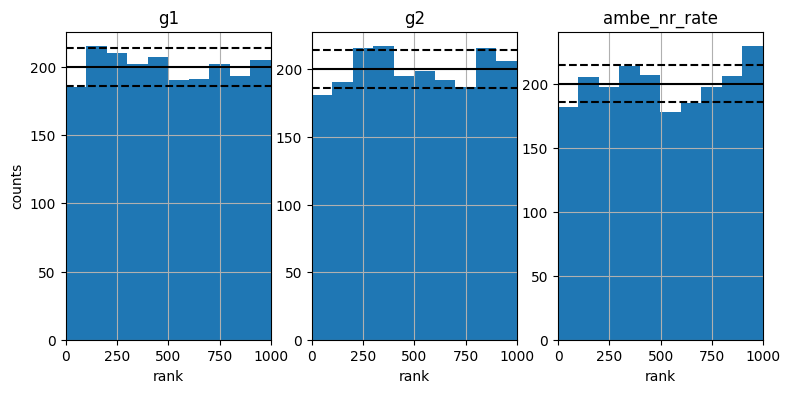

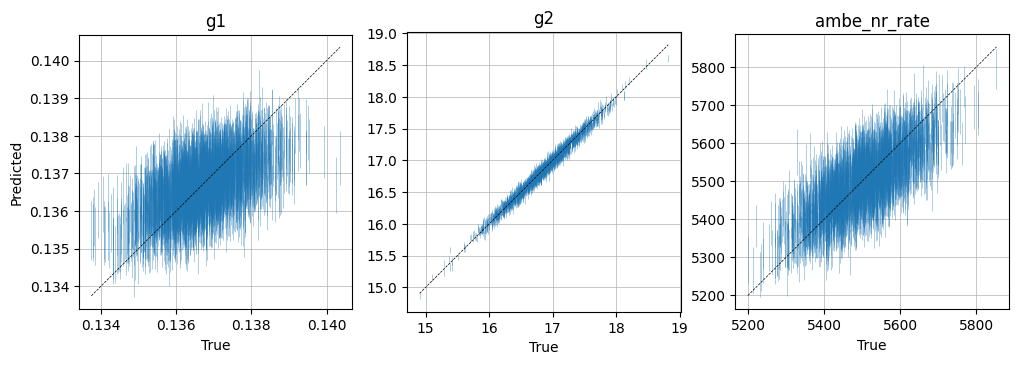

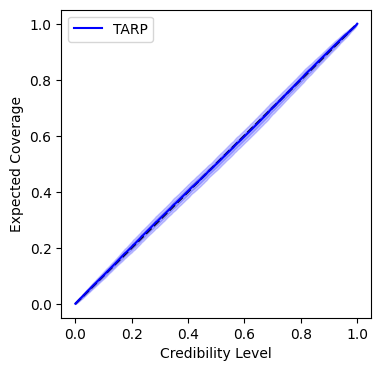

In [13]:
class HistDatasetX(data.Dataset):
    def __init__(self, x):
        self.x = x
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx]


metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=MODEL_DIR, labels=param_names,
    plot_list=['coverage', 'histogram', 'predictions', 'tarp'],
    save_samples=True,
)
fig = metric(
    posterior=posterior_ensemble,
    x=HistDatasetX(x_test2), theta=theta_test2,
)

In [14]:
MODEL_DIR

'3_param_trained_models/summary_sweep/50000totalsamples_summary_nsf_h32_t3'